<a href="https://colab.research.google.com/github/htaofeek01/random-forest-classifier/blob/main/performance_prediction(student_behaviour).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CPE Group 3 ANN project:
##Title: PREDICTING STUDENTS' PERFORMANCE USING BEHAVIOURAL DATA

##Aim: The aim of this project is to predict students academic performance with their behavioural dataset

In [ ]:
#importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import confusion_matrix, roc_curve, accuracy_score, f1_score, roc_auc_score, classification_report
from astropy.table import Table
from sklearn.metrics import roc_auc_score

#Dataset
##We created a survey(google form) which was filled by FUTA students from different departments

In [ ]:
# Loading the data into a DataFrame
data_path = '/student_data.csv'
df = pd.read_csv(data_path)

# show the first few rows of the dataset
df.head()

,Rate how often you attend classes,Rate your study habit,"Rate the level of financial support you have from home, family, and friends, and/or scholarship(s).",Rate the effect of side hustles on your academics (if you have any),Rate the effect of family issues and personal problems on your academics,"Rate how your lodge distance from school affects your academics (Select ""1"" if you live inside school)",Rate your extracurricular engagements,Rate how your extracurricular engagements affect your academics,"Rate how often you engage in hobbies (social media, gaming, movies, sports, clubbing, etc)",Rate how your hobbies affect your academics,What is your CGPA range?
0,5,5,5,1,5,1,1,1,1,1,4.0 - 5.0
1,5,5,5,3,4,1,5,5,5,5,4.0 - 5.0
2,4,3,5,1,2,1,1,2,4,4,2.0 - 2.99
3,3,3,2,4,4,5,5,4,5,5,2.0 - 2.99
4,3,3,4,4,3,2,3,4,4,4,2.0 - 2.99


##To display and examine *the* summary statistics (mean, standard deviation, minimum, 25th percentile, median, 75th percentile, and maximum) of the DataFrame "df."

In [ ]:
# Displaying summary statistics
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,Rate how often you attend classes,Rate your study habit,"Rate the level of financial support you have from home, family, and friends, and/or scholarship(s).",Rate the effect of side hustles on your academics (if you have any),Rate the effect of family issues and personal problems on your academics,"Rate how your lodge distance from school affects your academics (Select ""1"" if you live inside school)",Rate your extracurricular engagements,Rate how your extracurricular engagements affect your academics,"Rate how often you engage in hobbies (social media, gaming, movies, sports, clubbing, etc)",Rate how your hobbies affect your academics
count,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000,1247.000000
mean,4.127506,3.209302,3.614274,2.546111,3.462711,2.493986,2.842823,2.434643,2.921411,2.589415
std,0.959336,1.196025,1.199072,1.304732,1.391333,1.386042,1.248818,1.196042,1.242731,1.170045
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,2.000000,3.000000,1.000000,2.000000,1.000000,2.000000,1.000000,2.000000,1.500000
50%,4.000000,3.000000,4.000000,3.000000,4.000000,2.000000,3.000000,2.000000,3.000000,3.000000
75%,5.000000,4.000000,5.000000,4.000000,5.000000,3.000000,4.000000,3.000000,4.000000,3.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


#Data preprocessing
##The code block below is used to check for null or missing values in the dataset. The dataset is then normalized to prepare it for model training and prediction.

In [ ]:
#Data preprocessing and normalization
# Checking for missing values
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


Rate how often you attend classes                                                                          0
Rate your study habit                                                                                      0
Rate the level of financial support you have from home, family, and friends, and/or scholarship(s).        0
Rate the effect of side hustles on your academics (if you have any)                                        0
Rate the effect of family issues and personal problems on your academics                                   0
Rate how your lodge distance from school affects your academics (Select "1" if you live inside school)     0
Rate your extracurricular engagements                                                                      0
Rate how your extracurricular engagements affect your academics                                            0
Rate how often you engage in hobbies (social media, gaming, movies, sports, clubbing, etc)                 0
Rate how your hobbi

##The countplot function is used to visualize the distribution of student CGPA in the dataset

<ipython-input-11-82583963435d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='What is your CGPA range?', data=df, palette='viridis')


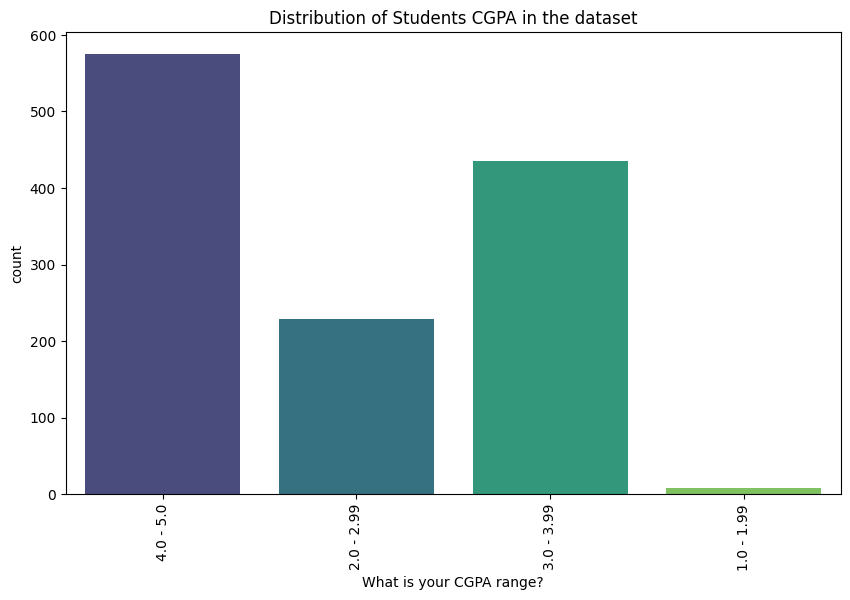

In [ ]:
#Using Seaborn to vizualize the distribution of students CGPA with respect to count values
plt.figure(figsize=(10, 6))
sns.countplot(x='What is your CGPA range?', data=df, palette='viridis')
plt.title('Distribution of Students CGPA in the dataset')
plt.xticks(rotation=90)  # Rotating x-axis labels vertically
plt.show()

In [ ]:
#Data is already preprocessed with numeric values

#drop null values if present
df.dropna().shape
print(df.shape)
#print columns(features)
df.columns

(1247, 11)


Index(['Rate how often you attend classes', 'Rate your study habit',
       'Rate the level of financial support you have from home, family, and friends, and/or scholarship(s).',
       'Rate the effect of side hustles on your academics (if you have any)',
       'Rate the effect of family issues and personal problems on your academics',
       'Rate how your lodge distance from school affects your academics (Select "1" if you live inside school) ',
       'Rate your extracurricular engagements ',
       'Rate how your extracurricular engagements affect your academics ',
       'Rate how often you engage in hobbies (social media, gaming, movies, sports, clubbing, etc)',
       'Rate how your hobbies affect your academics',
       'What is your CGPA range?'],
      dtype='object')

##We have to Rename the dataframe columns label for easy interpretation of our result and correlation analysis

In [ ]:
#Change the dataframe labels
# Define a dictionary for column renaming and feature mapping
new_col_names ={'Rate how often you attend classes':'Attendance',
       'Rate your study habit':'Study habit',
       'Rate the level of financial support you have from home, family, and friends, and/or scholarship(s).':'Financial stability',
       'Rate the effect of side hustles on your academics (if you have any)':'side hustles',
       'Rate the effect of family issues and personal problems on your academics':'family issues',
       'Rate how your lodge distance from school affects your academics (Select "1" if you live inside school) ':'Accommodation',
       'Rate your extracurricular engagements ':'Extracurricular activities',
       'Rate how your extracurricular engagements affect your academics ':'Impact of Extracurricular',
       'Rate how often you engage in hobbies (social media, gaming, movies, sports, clubbing, etc)':'distractions',
       'Rate how your hobbies affect your academics':'Impact of Hobbies',
       'What is your CGPA range?':'Grade'}

# Rename multiple columns using the rename() method
df.rename(columns=new_col_names, inplace=True)

# Display the DataFrame after renaming
print("\nDataFrame after renaming columns:")
df


DataFrame after renaming columns:


,Attendance,Study habit,Financial stability,side hustles,family issues,Accommodation,Extracurricular activities,Impact of Extracurricular,distractions,Impact of Hobbies,Grade
0,5,5,5,1,5,1,1,1,1,1,4.0 - 5.0
1,5,5,5,3,4,1,5,5,5,5,4.0 - 5.0
2,4,3,5,1,2,1,1,2,4,4,2.0 - 2.99
3,3,3,2,4,4,5,5,4,5,5,2.0 - 2.99
4,3,3,4,4,3,2,3,4,4,4,2.0 - 2.99
...,...,...,...,...,...,...,...,...,...,...,...
1242,4,3,4,2,2,4,3,2,4,2,3.0 - 3.99
1243,3,3,4,4,3,3,3,3,3,4,3.0 - 3.99
1244,4,5,5,4,5,1,2,2,3,3,4.0 - 5.0
1245,4,2,5,1,5,1,2,1,4,3,4.0 - 5.0


#Student Rating by Grade

## | CGPA | SCore(rating) | Remarks
 ---
## | 4.0 - 5.0  | 4 | Very Good
## |3.0 - 3.99  | 3 | Good
## |2.0 - 2.99  | 2 | Fair
## |1.0 - 1.99  | 1 | Weak
## |0.0 - 0.99  | 0 |Poor


In [ ]:

new_df=df #save the copy of transformed data to a new dataframe
new_df

#Recall that our new features are:
# features= ['Attendance', 'Study habit', 'Financial stability', 'side hustles',
#        'family issues', 'Accommodation', 'Extracurricular activities',
#        'Impact of Extracurricular', 'distractions', 'Impact of Hobbies',
#        'Grade','Score']



,Attendance,Study habit,Financial stability,side hustles,family issues,Accommodation,Extracurricular activities,Impact of Extracurricular,distractions,Impact of Hobbies,Grade
0,5,5,5,1,5,1,1,1,1,1,4.0 - 5.0
1,5,5,5,3,4,1,5,5,5,5,4.0 - 5.0
2,4,3,5,1,2,1,1,2,4,4,2.0 - 2.99
3,3,3,2,4,4,5,5,4,5,5,2.0 - 2.99
4,3,3,4,4,3,2,3,4,4,4,2.0 - 2.99
...,...,...,...,...,...,...,...,...,...,...,...
1242,4,3,4,2,2,4,3,2,4,2,3.0 - 3.99
1243,3,3,4,4,3,3,3,3,3,4,3.0 - 3.99
1244,4,5,5,4,5,1,2,2,3,3,4.0 - 5.0
1245,4,2,5,1,5,1,2,1,4,3,4.0 - 5.0


In [ ]:
#plot of student status
new_df['Grade'].value_counts()

4.0 - 5.0     575
3.0 - 3.99    435
2.0 - 2.99    229
1.0 - 1.99      8
Name: Grade, dtype: int64

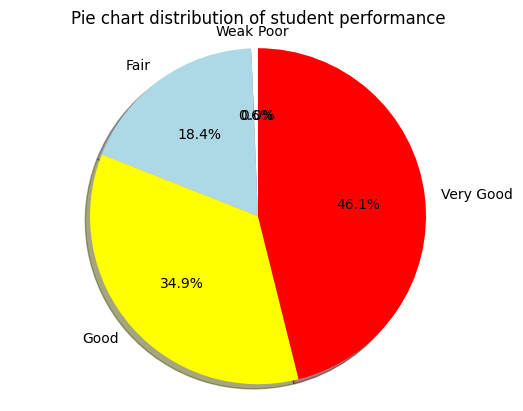

In [ ]:
#Labellings students by Grade
labels = 'Poor ', 'Weak','Fair','Good','Very Good'
sizes = [0,8, 229,435,575,]
colors=['black','white','lightblue','yellow','red']
fig1, ax1 = plt.subplots()
ax1.pie(sizes,  labels=labels, autopct='%1.1f%%',colors=colors,
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Pie chart distribution of student performance')
plt.show()

In [ ]:
#create a new column to map grade range to single value of 1-4
def extract_first_int(value):
    """Extracts the first integer from a string like "1-2"."""
    return int(value.split('.')[0])

# Apply the function to the desired column
new_df['Score'] = new_df['Grade'].apply(extract_first_int)

new_df

,Attendance,Study habit,Financial stability,side hustles,family issues,Accommodation,Extracurricular activities,Impact of Extracurricular,distractions,Impact of Hobbies,Grade,Score
0,5,5,5,1,5,1,1,1,1,1,4.0 - 5.0,4
1,5,5,5,3,4,1,5,5,5,5,4.0 - 5.0,4
2,4,3,5,1,2,1,1,2,4,4,2.0 - 2.99,2
3,3,3,2,4,4,5,5,4,5,5,2.0 - 2.99,2
4,3,3,4,4,3,2,3,4,4,4,2.0 - 2.99,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1242,4,3,4,2,2,4,3,2,4,2,3.0 - 3.99,3
1243,3,3,4,4,3,3,3,3,3,4,3.0 - 3.99,3
1244,4,5,5,4,5,1,2,2,3,3,4.0 - 5.0,4
1245,4,2,5,1,5,1,2,1,4,3,4.0 - 5.0,4


In [ ]:
#Normalizing the data
#Let's remove the Grade column so that the dataset is well prepared and normalized
new_df.drop('Grade', axis=1, inplace=True)
new_df

,Attendance,Study habit,Financial stability,side hustles,family issues,Accommodation,Extracurricular activities,Impact of Extracurricular,distractions,Impact of Hobbies,Score
0,5,5,5,1,5,1,1,1,1,1,4
1,5,5,5,3,4,1,5,5,5,5,4
2,4,3,5,1,2,1,1,2,4,4,2
3,3,3,2,4,4,5,5,4,5,5,2
4,3,3,4,4,3,2,3,4,4,4,2
...,...,...,...,...,...,...,...,...,...,...,...
1242,4,3,4,2,2,4,3,2,4,2,3
1243,3,3,4,4,3,3,3,3,3,4,3
1244,4,5,5,4,5,1,2,2,3,3,4
1245,4,2,5,1,5,1,2,1,4,3,4


In [ ]:
# see correlation between variables through a correlation
new_df= df #store our transformed dataset to another variable
corr = new_df.corr()
corr


,Attendance,Study habit,Financial stability,side hustles,family issues,Accommodation,Extracurricular activities,Impact of Extracurricular,distractions,Impact of Hobbies,Score
Attendance,1.000000,0.387313,0.319775,-0.096071,0.037538,-0.084226,-0.131307,-0.167947,-0.035345,-0.144943,0.200659
Study habit,0.387313,1.000000,0.233181,-0.132966,0.194476,-0.161183,-0.094558,-0.091698,-0.026722,-0.089947,0.227612
Financial stability,0.319775,0.233181,1.000000,-0.435699,0.243691,-0.205424,-0.264554,-0.160574,0.057198,-0.005430,0.130635
side hustles,-0.096071,-0.132966,-0.435699,1.000000,-0.183964,0.223050,0.373381,0.526644,0.184883,0.364121,-0.060482
family issues,0.037538,0.194476,0.243691,-0.183964,1.000000,0.034114,-0.178438,-0.208246,-0.064359,-0.285000,0.216033
Accommodation,-0.084226,-0.161183,-0.205424,0.223050,0.034114,1.000000,0.214131,0.178285,0.073810,-0.100996,-0.376498
Extracurricular activities,-0.131307,-0.094558,-0.264554,0.373381,-0.178438,0.214131,1.000000,0.673370,0.132696,0.287553,-0.008400
Impact of Extracurricular,-0.167947,-0.091698,-0.160574,0.526644,-0.208246,0.178285,0.673370,1.000000,0.194705,0.449358,-0.110313
distractions,-0.035345,-0.026722,0.057198,0.184883,-0.064359,0.073810,0.132696,0.194705,1.000000,0.522017,-0.155019
Impact of Hobbies,-0.144943,-0.089947,-0.005430,0.364121,-0.285000,-0.100996,0.287553,0.449358,0.522017,1.000000,-0.021686


Text(0.5, 1.0, 'Correlation Heatmap')

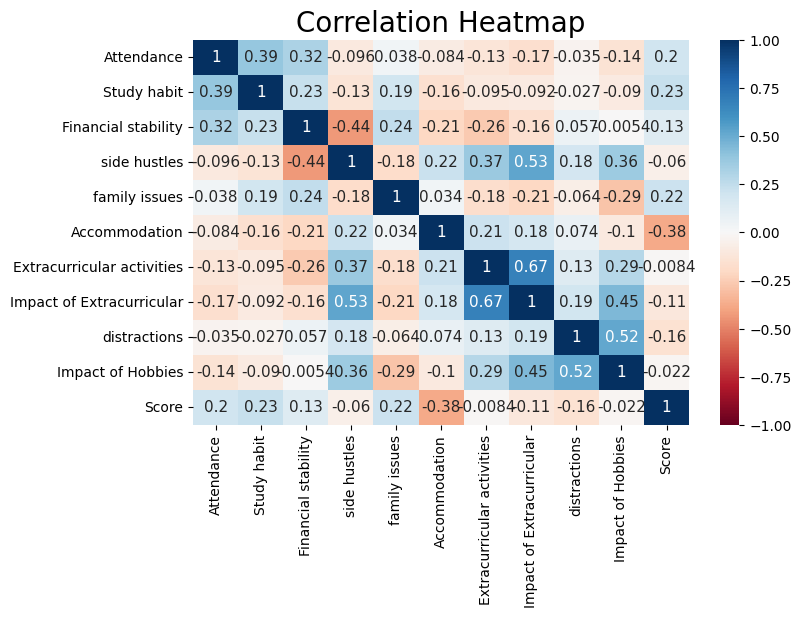

In [ ]:
#Correlation heat map
plt.figure(figsize=(8,5)) # figure size in terms of bread x height
sns.heatmap(corr, annot=True, cmap="RdBu", vmin=-1, vmax=1, annot_kws={'fontsize':11, })
plt.title('Correlation Heatmap', fontsize=20)

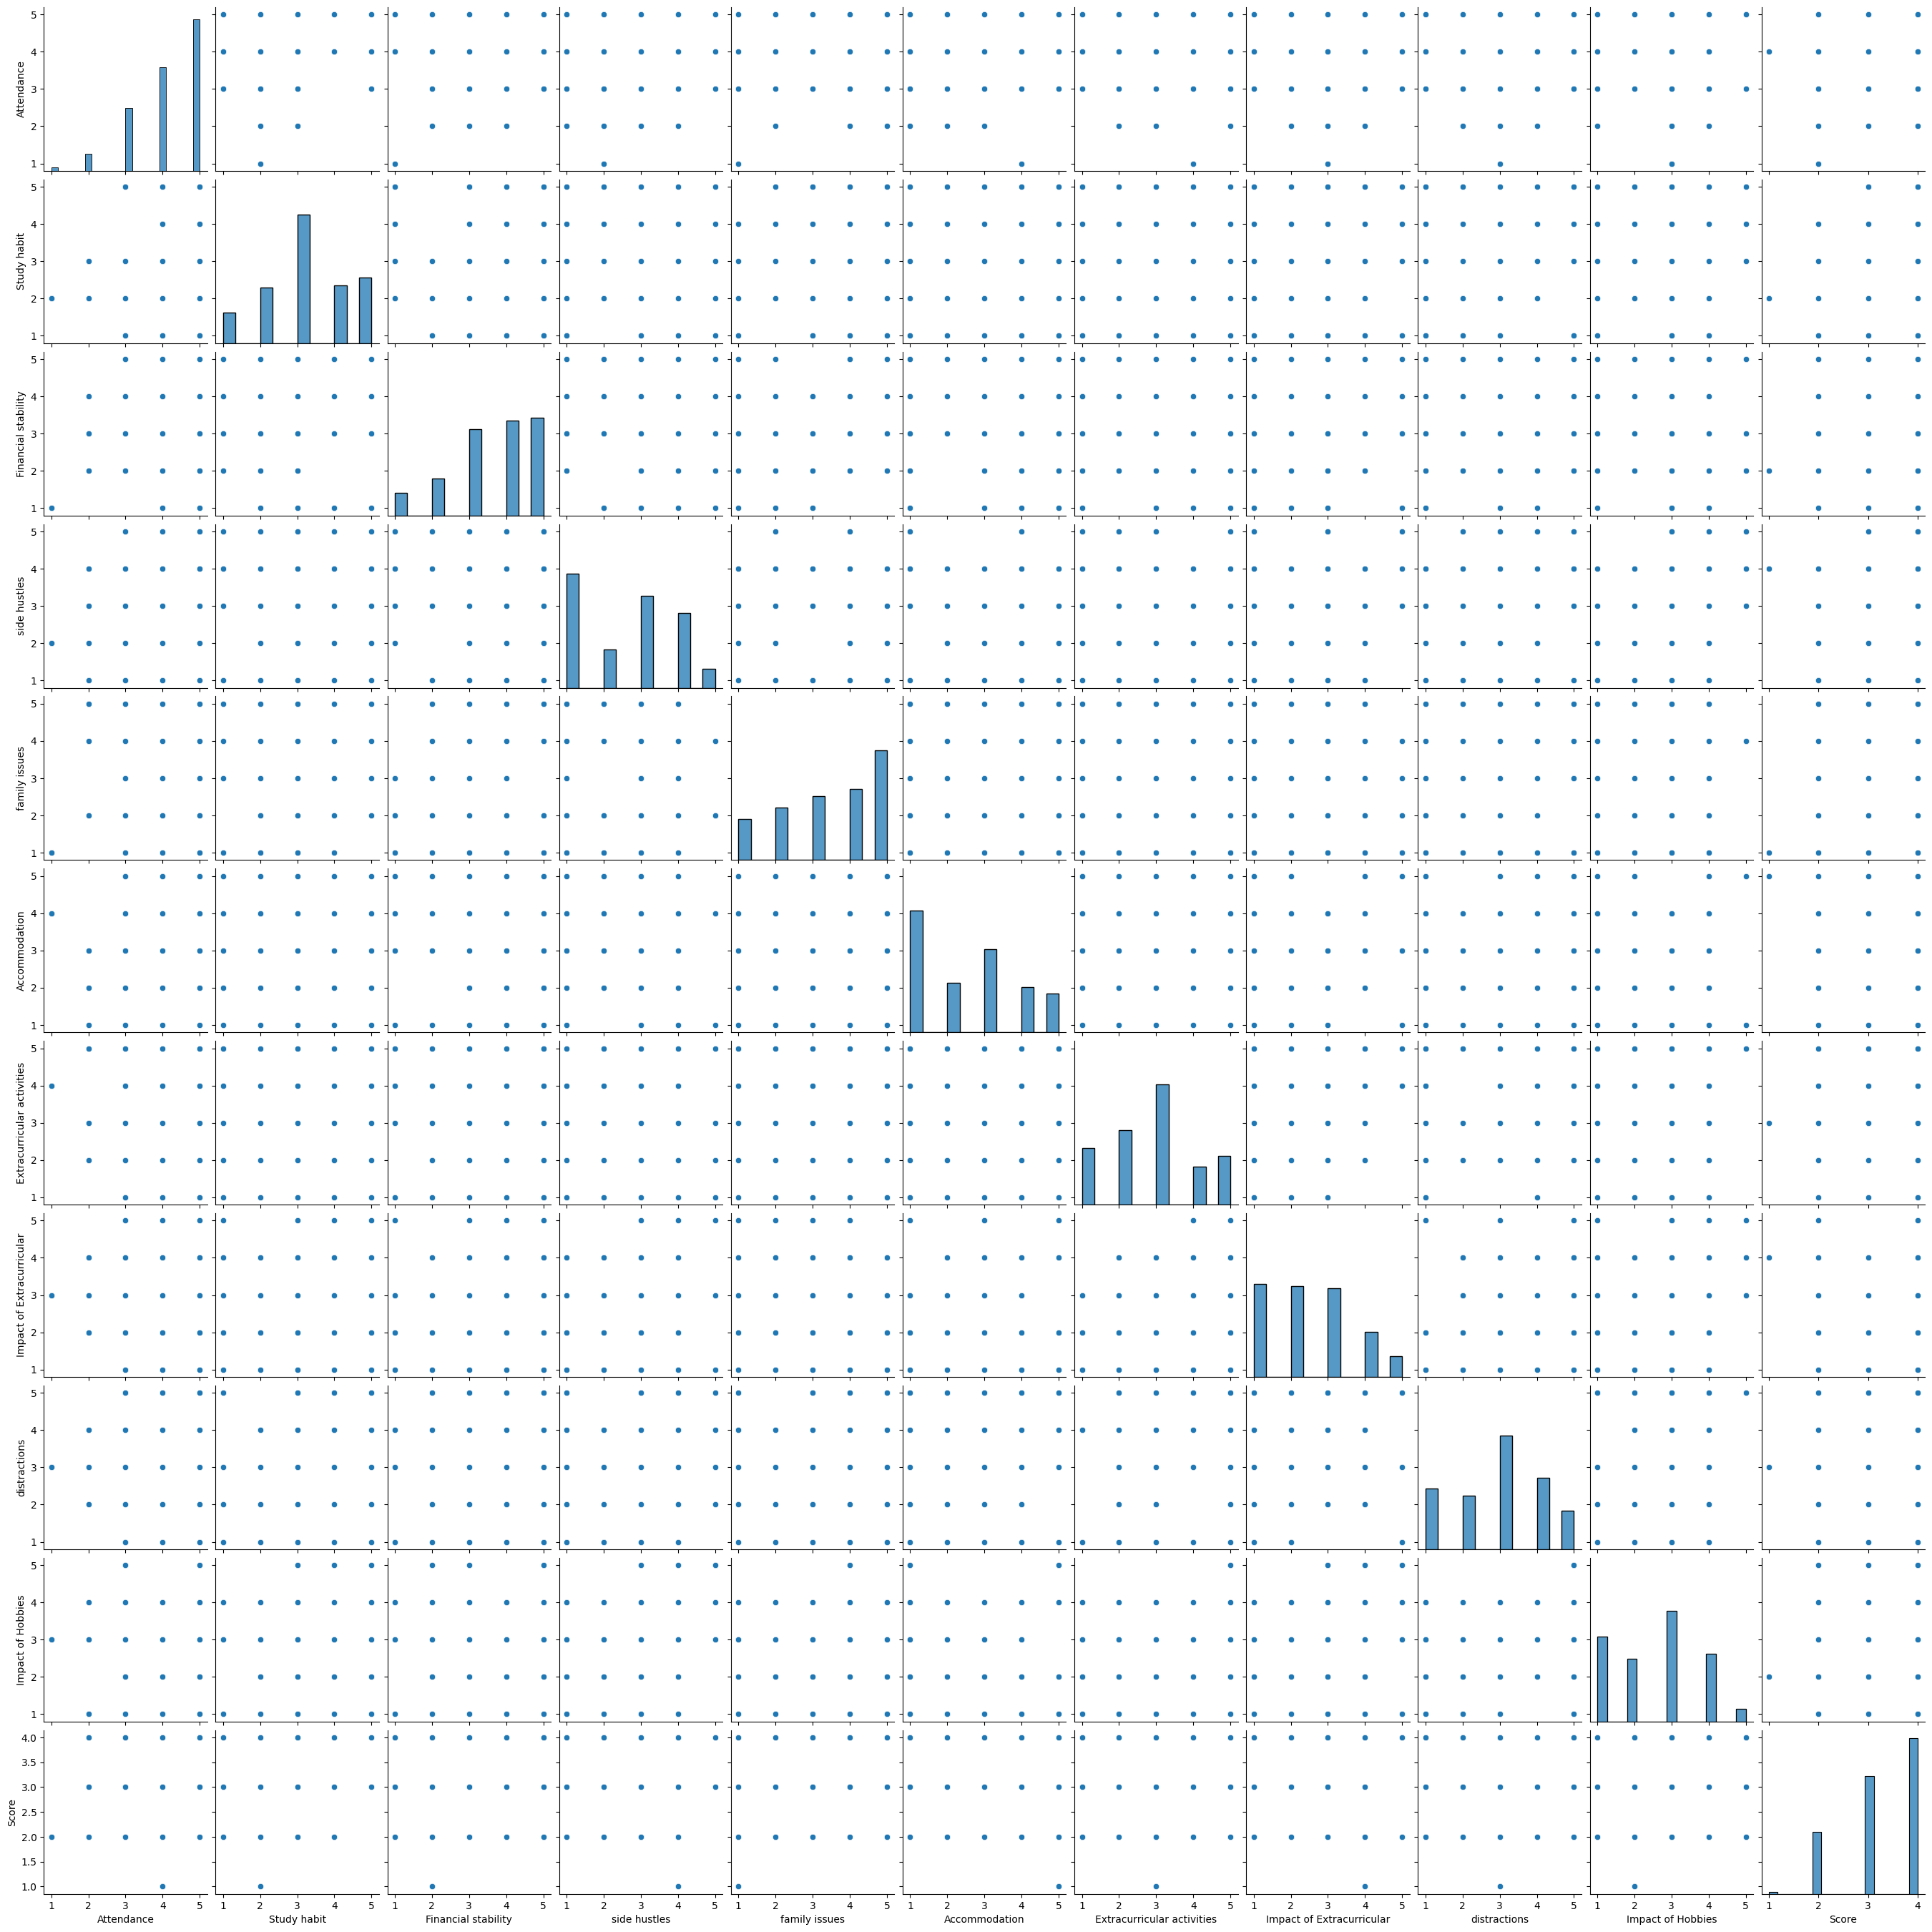

In [ ]:
#pair plot of the data
sns.pairplot(data=new_df)

#Correlation of student General performance
##The result of the graphs below shows the impact of negative and positive behaviour on student performance

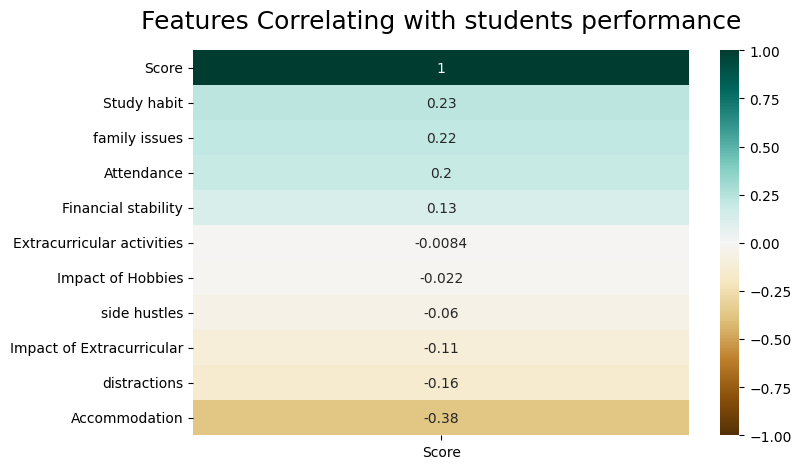

In [ ]:
#correlation of student status with other features
plt.figure(figsize=(8, 5))
heatmap = sns.heatmap(new_df.corr()[['Score']].sort_values(by='Score', ascending=False), vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Features Correlating with students performance', fontdict={'fontsize':18}, pad=16);


Text(0.5, 0, 'Students Rating(0-4)')

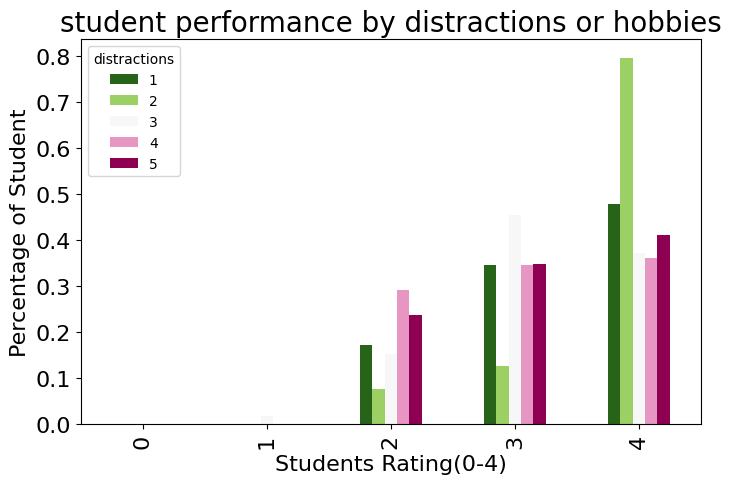

In [ ]:
# Checking for distractions(Hobbies)
percent = (lambda col: col/col.sum())
index = [0,1,2,3,4]

distract_tab = pd.crosstab(index=new_df.Score, columns=new_df.distractions)
distract_percent = distract_tab.apply(percent).reindex(index)
distract_percent.plot.bar(colormap="PiYG_r", fontsize=16, figsize=(8,5))
plt.title('student performance by distractions or hobbies', fontsize=20)
plt.ylabel('Percentage of Student', fontsize=16)
plt.xlabel('Students Rating(0-4)', fontsize=16)

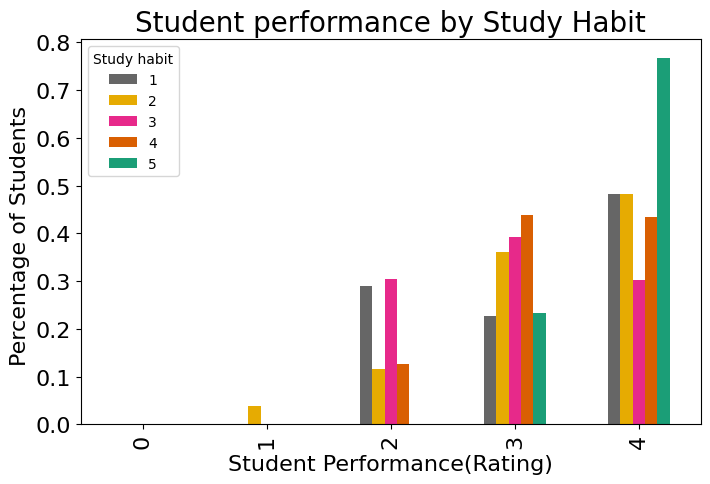

In [ ]:
# Effect of Study habit on student performance
study= new_df['Study habit']
studyh = pd.crosstab(index=new_df.Score, columns=study)
study_percent = studyh.apply(percent).reindex(index)
#plt.figure()
study_percent.plot.bar(colormap="Dark2_r", fontsize=16, figsize=(8,5))
plt.title('Student performance by Study Habit', fontsize=20)
plt.ylabel('Percentage of Students ', fontsize=16)
plt.xlabel('Student Performance(Rating)', fontsize=16)
plt.show()

Text(0.5, 0, 'Students Rating(0-4)')

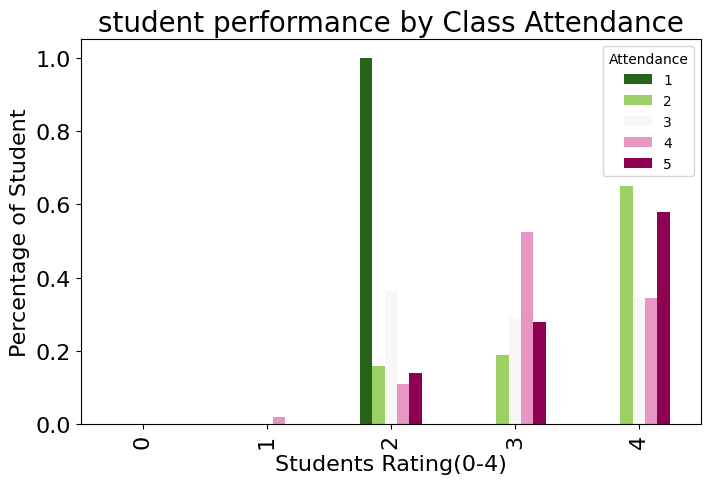

In [ ]:
#Impact of class attendance
attendance_tab = pd.crosstab(index=new_df.Score, columns=new_df.Attendance)
attendance_percent = attendance_tab.apply(percent).reindex(index)
attendance_percent.plot.bar(colormap="PiYG_r", fontsize=16, figsize=(8,5))
plt.title('student performance by Class Attendance', fontsize=20)
plt.ylabel('Percentage of Student', fontsize=16)
plt.xlabel('Students Rating(0-4)', fontsize=16)

<Figure size 640x480 with 0 Axes>

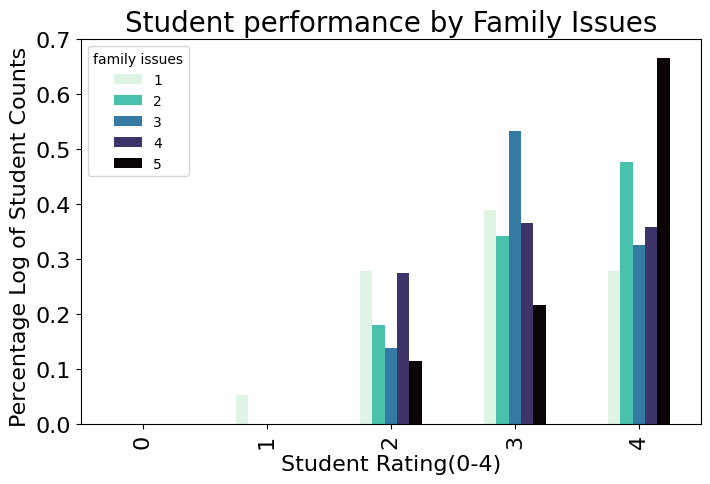

In [ ]:
# Impact of Family issues on student performance
family= new_df['family issues']
family_prob = pd.crosstab(index=new_df.Score, columns=family)

family_percent = family_prob.apply(percent).reindex(index)
plt.figure()
family_percent.plot.bar(colormap="mako_r", fontsize=16, figsize=(8,5))
plt.title('Student performance by Family Issues', fontsize=20)
plt.ylabel('Percentage Log of Student Counts ', fontsize=16)
plt.xlabel('Student Rating(0-4)', fontsize=16)
plt.show()

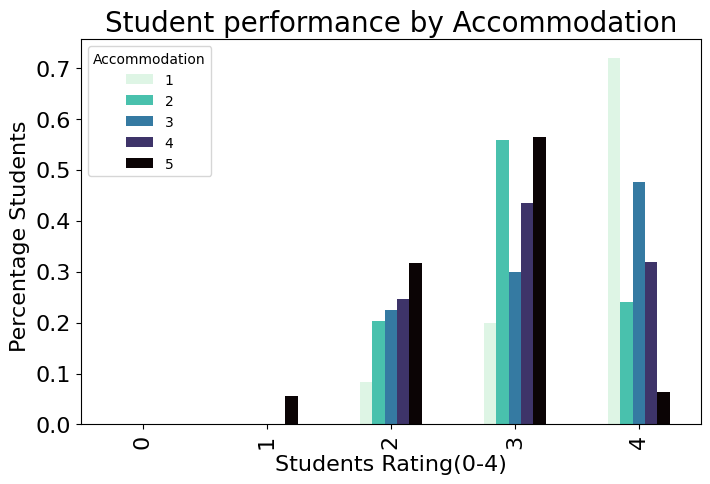

In [ ]:
# Impact of Accommodation on Student performance
accomm_prob = pd.crosstab(index=new_df.Score, columns=new_df.Accommodation)

accomm_percent = accomm_prob.apply(percent).reindex(index)
#plt.figure()
accomm_percent.plot.bar(colormap="mako_r", fontsize=16, figsize=(8,5))
plt.title('Student performance by Accommodation', fontsize=20)
plt.ylabel('Percentage Students ', fontsize=16)
plt.xlabel('Students Rating(0-4)', fontsize=16)
plt.show()

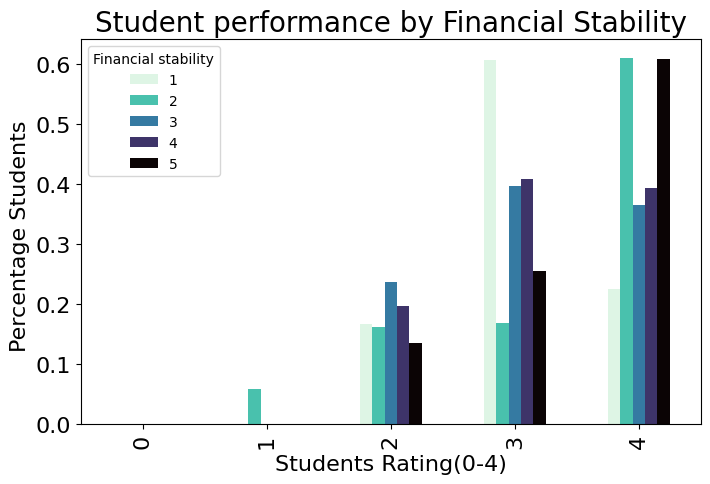

In [ ]:
# Impact of Financial support on Students performance
finance =new_df['Financial stability']
fin_prob = pd.crosstab(index=new_df.Score, columns=finance)

fin_percent = fin_prob.apply(percent).reindex(index)
#plt.figure()
fin_percent.plot.bar(colormap="mako_r", fontsize=16, figsize=(8,5))
plt.title('Student performance by Financial Stability', fontsize=20)
plt.ylabel('Percentage Students ', fontsize=16)
plt.xlabel('Students Rating(0-4)', fontsize=16)
plt.show()

#Random Forest classifier

In [ ]:
# # Preprocess the data
# le = LabelEncoder()
# df["grade"] = le.fit_transform(df["grade"])  # Encode the target variable as numerical

# Separate features and target variable
#x_train and y_train are the samples we will use to train the model
# Once we split the data, we can ignore x_test and y_test until we define our model.
X = new_df[["Attendance", "Study habit", "family issues","Financial stability","Accommodation"]]
y = df["Score"]

# Split the data into training and testing sets
#perform a train_test_split(80 for training, 20 for testing)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Create a Random Forest classifier with hyperparameter tuning
clf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# # let's create a model and train it
clf.fit(X_train, y_train)




RandomForestClassifier(max_depth=5, random_state=42)

In [ ]:
# Make predictions on the testing set
y_pred = clf.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.828


In [ ]:
# Save the trained model to a file
joblib.dump(clf, "student_performance_model.pkl")


['student_performance_model.pkl']

In [ ]:
# Load the saved model
loaded_model = joblib.load("student_performance_model.pkl")


In [ ]:
# Get user input for new student data

def get_user_input_and_predict(loaded_model):
    # Get user input for features
    attendance = int(input("Enter attendance score (1-5): "))
    study_habit = int(input("Enter study habit score (1-5): "))
    family_issues = int(input("Enter family issues score (1-5): "))
    financial_stability = int(input("Enter financial stability score (1-5): "))
    accommodation = int(input("Enter accommodation score (1-5): "))



      # Create a DataFrame with user input
    user_input = pd.DataFrame([[attendance, study_habit, family_issues, financial_stability,accommodation]], columns=['Attendance', 'Study habit', 'family issues','Financial stability','Accommodation'])

    # Make prediction
    prediction = loaded_model.predict(user_input)
    if prediction[0] == 4:
      print("\nPredicted Student Performance: Very Good")
    elif prediction[0] == 3:
      print("\nPredicted Student Performance: Good")
    elif prediction[0] == 2:
      print("\nPredicted Student Performance: Fair")
    elif prediction[0] == 1:
      print("\nPredicted Student Performance: Weak")
    elif prediction[0] == 0:
      print("\nPredicted Student Performance: Poor")

In [ ]:
# Testing the model usage
get_user_input_and_predict(clf)

Enter attendance score (1-5): 2
Enter study habit score (1-5): 3
Enter family issues score (1-5): 4
Enter financial stability score (1-5): 1
Enter accommodation score (1-5): 5

Predicted Student Performance: Fair


In [ ]:
#Testing the model for another student
get_user_input_and_predict(clf)

Enter attendance score (1-5): 4
Enter study habit score (1-5): 5
Enter family issues score (1-5): 3
Enter financial stability score (1-5): 3
Enter accommodation score (1-5): 1

Predicted Student Performance: Very Good


In [ ]:
#Testing the model with third user
get_user_input_and_predict(clf)


Enter attendance score (1-5): 3
Enter study habit score (1-5): 3
Enter family issues score (1-5): 2
Enter financial stability score (1-5): 4
Enter accommodation score (1-5): 2

Predicted Student Performance: Good


In [ ]:
#import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00         2
           2       0.79      0.62      0.70        48
           3       0.84      0.86      0.85        88
           4       0.82      0.88      0.85       112

    accuracy                           0.83       250
   macro avg       0.86      0.84      0.85       250
weighted avg       0.83      0.83      0.82       250



In [ ]:
#F1 score


0.8512638196840957

Text(0.5, 1.0, 'Confusion Matrix')

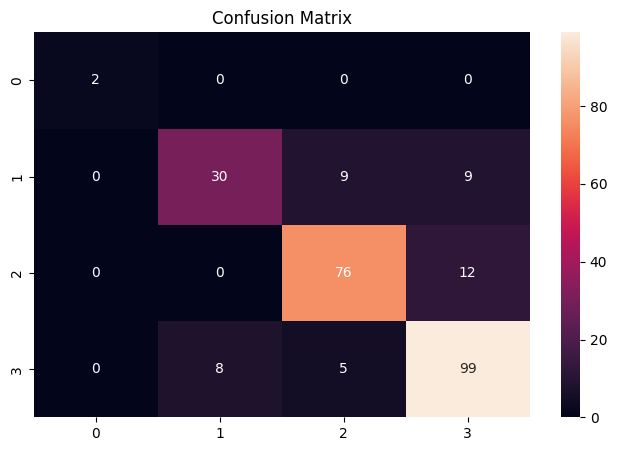

In [ ]:
#visualizig the confusion matrix:
plt.figure(figsize=(8, 5))
cm = confusion_matrix(y_test, y_pred) #confusion matrix
sns.heatmap(cm,annot=True)
plt.title("Confusion Matrix")